In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]='0'
os.environ["HF_HOME"]="~/codes/.cache/huggingface"

In [2]:
from accelerate.utils import ProjectConfiguration, set_seed

/home/teoaivalis/.conda/envs/dtrak/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/teoaivalis/.conda/envs/dtrak/lib/python3.8/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/teoaivalis/.conda/envs/dtrak/lib/python3.8/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [3]:
import torch
import random
import numpy as np

def set_seeds(seed):
    set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seeds(42)

In [4]:
from torchvision import transforms
from diffusers import DDPMPipeline, DDIMPipeline, DDPMScheduler, DDIMScheduler, UNet2DModel

/home/teoaivalis/.conda/envs/dtrak/lib/python3.8/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [5]:
import pickle

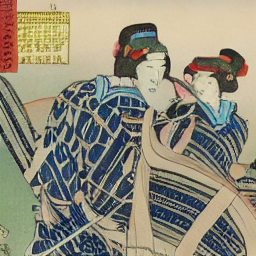

In [6]:
import pandas as pd
df = pd.DataFrame()
df['label'] = ['ukiyo_e']*500+['post_impressionism']*500
df['path'] = ['{}/{}.png'.format('saved/5000-0.5/gen', i) for i in range(1000)]

from datasets import DatasetDict, Dataset, load_dataset, Image
dataset = DatasetDict({
"train": Dataset.from_dict({
    "image": df['path'].tolist(),
    "label": df['label'].tolist(),
}).cast_column("image", Image()),})
gen_dataset = dataset["train"]
gen_dataset[0]["image"]

In [7]:
class Args():
    
    pretrained_model_name_or_path="lambdalabs/miniSD-diffusers"
    

    resolution=256
    center_crop=True
    random_flip=False

    dataloader_num_workers=8
    
    seed=42
    gen_seed=0    

    train_batch_size=256

    ddpm_num_steps=1000
    ddpm_num_inference_steps=50
    ddpm_beta_schedule='linear'

args=Args()


In [8]:
with open('./data/indices/5000-0.5/counter/idx-gen-sampled.pkl', 'rb') as handle:
    test_index = pickle.load(handle)
test_index[0:5]

[993, 859, 298, 553, 672]

In [9]:
import os
import pickle
from sklearn.model_selection import train_test_split

# 1. Define and create the directory
counter_dir = "/home/teoaivalis/neurips/D-TRAK/ArtBench2/data/indices/5000-0.5/counter/"
os.makedirs(counter_dir, exist_ok=True)

# 2. Generate the 60 indices (Must use random_state=0 to match the paper)
# This assumes you have 1000 generated images total
_, test_index = train_test_split(range(1000), test_size=60, random_state=0)

# 3. Save the file where the notebook expects it
file_path = os.path.join(counter_dir, "idx-gen-sampled.pkl")
with open(file_path, 'wb') as handle:
    pickle.dump(test_index, handle)

print(f"Success! Created {file_path}")
print(f"Sampled indices: {test_index[:5]}")

Success! Created /home/teoaivalis/neurips/D-TRAK/ArtBench2/data/indices/5000-0.5/counter/idx-gen-sampled.pkl
Sampled indices: [993, 859, 298, 553, 672]


In [10]:
# Update this line in your generation script:
with open('../../data/indices/5000-0.5/counter/idx-gen-sampled.pkl', 'rb') as handle:
    test_index = pickle.load(handle)
test_index[0:5]

[993, 859, 298, 553, 672]

In [11]:
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
from diffusers import DDIMScheduler

In [13]:
index_image_list = []
for index, my_i in enumerate(test_index):
    print(index, my_i)
        
    print(index, my_i)
    k_image_list = []
    for k in [
        500, 
        #1000
    ]:
        method_image_list = []
        for method in ['Random', 'TRAK', 
                       'Ours'
                      ]:
            # If passed along, set the training seed now.
            if args.seed is not None:
                set_seeds(args.seed)
            ####    
            print(args.pretrained_model_name_or_path)
            pipe = StableDiffusionPipeline.from_pretrained(args.pretrained_model_name_or_path, 
                                                           torch_dtype=torch.float16).to('cuda')
            ####
            pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
            print('DDIM!')
            ####
            def dummpy(images, **kwargs):
                return images, False
            
            pipe.safety_checker = dummpy
            ####
            args.model_path = "./saved/5000-0.5/counter/sd-lora-sub-{}-{}-{}-42".format(index, k, method)
            # args.model_path = "./saved/5000-0.5/counter/sd-lora"
            print(args.model_path)
            ####    
            pipe.unet.load_attn_procs(args.model_path)
            pipe.unet.eval()
            ####
            
            generator = [torch.Generator('cpu').manual_seed(my_i)]
            if my_i>=500:
                prompt_list = ['a post impressionism painting']
            else:
                prompt_list = ['a ukiyo e painting']
                
            images = pipe(prompt_list, 
                  height=args.resolution, 
                  width=args.resolution,
                  num_inference_steps=50, 
                      generator=generator, 
                      eta=0.0).images
        
            method_image_list.append(images[0])
        k_image_list.append(method_image_list)
    index_image_list.append(k_image_list)
    # break

0 993
0 993
lambdalabs/miniSD-diffusers


text_encoder/model.safetensors not found
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


DDIM!
./saved/5000-0.5/counter/sd-lora-sub-0-500-Random-42


OSError: We couldn't connect to 'https://huggingface.co' to load this model, couldn't find it in the cached files and it looks like ./saved/5000-0.5/counter/sd-lora-sub-0-500-Random-42 is not the path to a directory containing a file named pytorch_lora_weights.bin or 
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/diffusers/installation#offline-mode'.

In [11]:
test_index_ = []
for index, my_i in enumerate(test_index):
    
    # if index%10>=1:
        # continue
    test_index_.append(my_i)
test_index_

[993,
 859,
 298,
 553,
 672,
 971,
 27,
 231,
 306,
 706,
 496,
 558,
 784,
 239,
 578,
 55,
 906,
 175,
 14,
 77,
 31,
 481,
 310,
 311,
 883,
 788,
 45,
 103,
 760,
 1,
 823,
 710,
 614,
 790,
 408,
 736,
 957,
 366,
 918,
 267,
 230,
 996,
 635,
 698,
 251,
 783,
 819,
 141,
 316,
 587,
 331,
 295,
 262,
 432,
 862,
 582,
 272,
 270,
 987,
 319]

In [12]:
j = 5

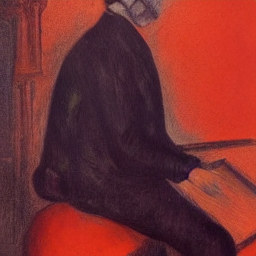

In [13]:
gen_dataset[test_index_[j]]['image']

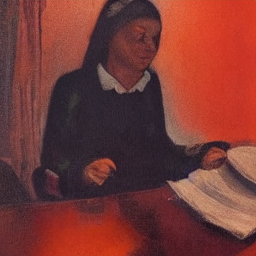

In [14]:
index_image_list[j][0][0]

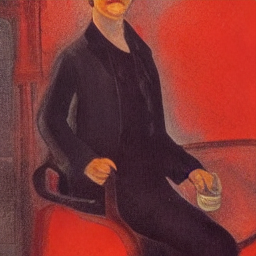

In [15]:
index_image_list[j][0][1]

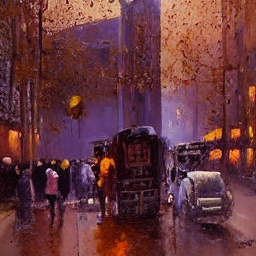

In [16]:
index_image_list[j][0][2]

In [17]:
with open("./counter/saved.pkl", 'wb') as handle:
    pickle.dump(index_image_list, handle)